# DL Experiments - улучшение baseline

## План экспериментов

В ноутбуке сравниваются:

1. Baseline: ResNet-18 с замороженным backbone и лёгкими аугментациями.
2. ResNet-18 + stronger augmentation: усиленные аугментации.
3. ResNet-18 fine-tuning: разморозка последнего блока backbone.
4. MobileNetV2: лёгкая transfer learning модель.
5. EfficientNet-B0: более современная CNN-архитектура.
6. ViT-B/16: transformer-based модель с self-attention и fine-tuning последних encoder-блоков.

ResNet-18 дополнительно закрывает проверку архитектуры со skip-connections, так как residual-блоки используют остаточные связи. ViT-B/16 закрывает проверку attention-подхода, так как Vision Transformer использует self-attention для обработки патчей изображения.

Для каждого эксперимента фиксируются модель, архитектура, гиперпараметры, аугментации, Accuracy, Macro F1, ROC-AUC macro и время обучения.


In [ ]:
import os
import time
import copy
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
import shutil
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

In [ ]:
INPUT_ROOT = Path("/kaggle/input/datasets/ivancloudmalyshev/project/project1_ML")
ROOT = Path("/kaggle/working/datasets/ivancloudmalyshev/project/project1_ML")
RAW_DIR = INPUT_ROOT / "data" / "raw"
IMG_DIR = RAW_DIR / "images"
SPLITS_DIR = INPUT_ROOT / "data" / "splits"
RESULTS_DIR = ROOT / "results"
MODELS_DIR = ROOT / "models"
PLOTS_DIR = ROOT / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 10
SAMPLE_FRACTION = 1.0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)
print("ROOT:", ROOT)
print("IMG_DIR:", IMG_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
assert IMG_DIR.exists(), f"Не найдена папка изображений: {IMG_DIR}"
assert (SPLITS_DIR / "train.csv").exists(), f"Не найден train.csv: {SPLITS_DIR / 'train.csv'}"
assert (SPLITS_DIR / "val.csv").exists(), f"Не найден val.csv: {SPLITS_DIR / 'val.csv'}"
assert (SPLITS_DIR / "test.csv").exists(), f"Не найден test.csv: {SPLITS_DIR / 'test.csv'}"

DEVICE: cuda
ROOT: /kaggle/working/datasets/ivancloudmalyshev/project/project1_ML
IMG_DIR: /kaggle/input/datasets/ivancloudmalyshev/project/project1_ML/data/raw/images
SPLITS_DIR: /kaggle/input/datasets/ivancloudmalyshev/project/project1_ML/data/splits


## Загрузка данных

In [3]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
display(train_df.head())

def make_image_path(image_name):
    image_name = str(image_name)
    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        image_name = image_name + ".jpg"
    return str(IMG_DIR / image_name)

for df_part in [train_df, val_df, test_df]:
    df_part["image_path"] = df_part["image"].apply(make_image_path)

if "y" in train_df.columns:
    for df_part in [train_df, val_df, test_df]:
        df_part["target"] = df_part["y"].astype(int)
else:
    classes = sorted(train_df["label"].astype(str).unique())
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    for df_part in [train_df, val_df, test_df]:
        df_part["label"] = df_part["label"].astype(str)
        df_part["target"] = df_part["label"].map(class_to_idx).astype(int)

if SAMPLE_FRACTION < 1.0:
    train_df = train_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)

    val_df = val_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)

    test_df = test_df.groupby("target", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * SAMPLE_FRACTION)), random_state=SEED)
    ).reset_index(drop=True)

classes_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

if "label" in classes_df.columns:
    label_map = (
        classes_df[["target", "label"]]
        .drop_duplicates()
        .sort_values("target")
    )
    classes = label_map["label"].astype(str).tolist()
else:
    classes = [str(i) for i in sorted(classes_df["target"].unique())]

class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for i, cls in enumerate(classes)}

for name, df_part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    found = df_part["image_path"].apply(lambda x: Path(x).exists()).sum()
    print(f"{name}: найдено изображений {found} из {len(df_part)}")

print("Классы:", classes)
print("Train distribution:")
print(train_df["target"].value_counts(normalize=True).sort_index().round(3))

train: (7010, 4)
val: (1502, 4)
test: (1503, 4)


,image,label,path,y
0,ISIC_0031775.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
1,ISIC_0027306.jpg,mel,/content/drive/MyDrive/project1_ML/data/raw/im...,4
2,ISIC_0033895.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
3,ISIC_0025491.jpg,nv,/content/drive/MyDrive/project1_ML/data/raw/im...,5
4,ISIC_0031023.jpg,mel,/content/drive/MyDrive/project1_ML/data/raw/im...,4


train: найдено изображений 7010 из 7010
val: найдено изображений 1502 из 1502
test: найдено изображений 1503 из 1503
Классы: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train distribution:
target
0    0.033
1    0.051
2    0.110
3    0.012
4    0.111
5    0.669
6    0.014
Name: proportion, dtype: float64


## Train / validation / test split

Используется стратифицированное разбиение 70/15/15, чтобы сохранить распределение классов во всех выборках.

In [4]:
print("Используем готовые split-файлы:")
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

Используем готовые split-файлы:
train: (7010, 6)
val: (1502, 6)
test: (1503, 6)


## Dataset и аугментации

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["target"])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
light_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
strong_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

def make_loaders(train_transform, batch_size=BATCH_SIZE):
    train_ds = SkinLesionDataset(train_df, transform=train_transform)
    val_ds = SkinLesionDataset(val_df, transform=valid_transform)
    test_ds = SkinLesionDataset(test_df, transform=valid_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

## Веса классов

Из-за дисбаланса классов используется CrossEntropyLoss с весами классов. Редкие классы получают больший вес в функции потерь.

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["target"].unique())),
    y=train_df["target"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(class_weights)

tensor([ 4.3731,  2.7817,  1.3022, 12.3633,  1.2855,  0.2134, 10.1154],
       device='cuda:0')


## Функции обучения и оценки

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(device)
        targets = targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        all_probs.append(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())
    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    try:
        roc_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
    except Exception:
        roc_auc = np.nan

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "roc_auc_macro": roc_auc,
        "targets": all_targets,
        "preds": all_preds,
        "probs": all_probs,
    }

def run_training(model, train_loader, val_loader, optimizer, criterion, epochs, experiment_name):
    model = model.to(DEVICE)
    best_state = copy.deepcopy(model.state_dict())
    best_f1 = -1.0
    history = []
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_roc_auc_macro": val_metrics["roc_auc_macro"],
        }
        history.append(row)
        print(
            f"[{experiment_name}] epoch {epoch}/{epochs} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} | "
            f"val_auc={val_metrics['roc_auc_macro']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
    train_time = time.time() - start_time
    model.load_state_dict(best_state)

    return model, pd.DataFrame(history), train_time

## Создание моделей

Все модели используют transfer learning: backbone берётся из ImageNet, а финальный классификатор заменяется под количество классов в HAM10000.

In [ ]:
num_classes = len(classes)

def set_parameter_requires_grad(model, trainable=False):
    for param in model.parameters():
        param.requires_grad = trainable

def build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.2):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    if unfreeze_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def build_mobilenet_v2(freeze_backbone=True, dropout=0.2):
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def build_efficientnet_b0(freeze_backbone=True, unfreeze_last_blocks=False, dropout=0.3):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    if unfreeze_last_blocks:
        for param in model.features[-2:].parameters():
            param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def build_vit_b16(freeze_backbone=True, unfreeze_last_blocks=True, dropout=0.3):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    if freeze_backbone:
        set_parameter_requires_grad(model, trainable=False)
    if unfreeze_last_blocks:
        for layer in model.encoder.layers[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Описание экспериментов

In [9]:
experiments = [
    {
        "name": "baseline_resnet18_frozen_light_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.2),
        "augmentation": "light",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "architecture": "CNN, ResNet, skip-connections",
        "description": "Baseline: ResNet-18, frozen backbone, light augmentation"
    },
    {
        "name": "resnet18_frozen_strong_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=False, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "architecture": "CNN, ResNet, skip-connections",
        "description": "ResNet-18, frozen backbone, stronger image augmentation"
    },
    {
        "name": "resnet18_layer4_finetune_strong_aug",
        "model_fn": lambda: build_resnet18(freeze_backbone=True, unfreeze_layer4=True, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "AdamW",
        "lr": 3e-4,
        "batch_size": 32,
        "epochs": EPOCHS,
        "architecture": "CNN, ResNet, skip-connections, fine-tuning",
        "description": "ResNet-18, fine-tuning layer4, strong augmentation"
    },
    {
        "name": "mobilenet_v2_frozen_strong_aug",
        "model_fn": lambda: build_mobilenet_v2(freeze_backbone=True, dropout=0.2),
        "augmentation": "strong",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": EPOCHS,
        "architecture": "CNN, lightweight transfer learning",
        "description": "MobileNetV2, lightweight transfer learning model"
    },
    {
        "name": "efficientnet_b0_last_blocks_strong_aug",
        "model_fn": lambda: build_efficientnet_b0(freeze_backbone=True, unfreeze_last_blocks=True, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "AdamW",
        "lr": 1e-4,
        "batch_size": 32,
        "epochs": EPOCHS,
        "architecture": "CNN, EfficientNet, fine-tuning",
        "description": "EfficientNet-B0, fine-tuning last blocks, strong augmentation"
    },
    {
        "name": "vit_b16_last_blocks_strong_aug",
        "model_fn": lambda: build_vit_b16(freeze_backbone=True, unfreeze_last_blocks=True, dropout=0.3),
        "augmentation": "strong",
        "optimizer": "AdamW",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": EPOCHS,
        "architecture": "Transformer, ViT, self-attention, fine-tuning",
        "description": "Vision Transformer B/16, fine-tuning last encoder blocks, self-attention, strong augmentation"
    },
]

pd.DataFrame([
    {k: v for k, v in exp.items() if k != "model_fn"}
    for exp in experiments
])


,name,augmentation,optimizer,lr,batch_size,epochs,architecture,description
0,baseline_resnet18_frozen_light_aug,light,Adam,0.00100,32,10,"CNN, ResNet, skip-connections","Baseline: ResNet-18, frozen backbone, light au..."
1,resnet18_frozen_strong_aug,strong,Adam,0.00100,32,10,"CNN, ResNet, skip-connections","ResNet-18, frozen backbone, stronger image aug..."
2,resnet18_layer4_finetune_strong_aug,strong,AdamW,0.00030,32,10,"CNN, ResNet, skip-connections, fine-tuning","ResNet-18, fine-tuning layer4, strong augmenta..."
3,mobilenet_v2_frozen_strong_aug,strong,Adam,0.00100,32,10,"CNN, lightweight transfer learning","MobileNetV2, lightweight transfer learning model"
4,efficientnet_b0_last_blocks_strong_aug,strong,AdamW,0.00010,32,10,"CNN, EfficientNet, fine-tuning","EfficientNet-B0, fine-tuning last blocks, stro..."
5,vit_b16_last_blocks_strong_aug,strong,AdamW,0.00001,16,10,"Transformer, ViT, self-attention, fine-tuning","Vision Transformer B/16, fine-tuning last enco..."


## Запуск экспериментов

После запуска результаты сохраняются в results/ml_experiments_results.csv, истории обучения - в results/history_*.csv, лучшие веса моделей - в models/.

In [ ]:
all_results = []
all_histories = {}

for exp in experiments:
    print("=" * 100)
    print(exp["name"])
    print(exp["description"])
    train_transform = light_train_transform if exp["augmentation"] == "light" else strong_train_transform
    train_loader, val_loader, test_loader = make_loaders(train_transform, batch_size=exp["batch_size"])
    model = exp["model_fn"]()
    trainable_params = count_trainable_params(model)
    print("Trainable parameters:", trainable_params)
    params = [p for p in model.parameters() if p.requires_grad]
    if exp["optimizer"] == "AdamW":
        optimizer = torch.optim.AdamW(params, lr=exp["lr"], weight_decay=1e-4)
    else:
        optimizer = torch.optim.Adam(params, lr=exp["lr"])
    trained_model, history, train_time_sec = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=exp["epochs"],
        experiment_name=exp["name"]
    )
    test_metrics = evaluate(trained_model, test_loader, criterion, DEVICE)
    history_path = RESULTS_DIR / f"history_{exp['name']}.csv"
    model_path = MODELS_DIR / f"best_{exp['name']}.pt"
    history.to_csv(history_path, index=False)
    torch.save(trained_model.state_dict(), model_path)
    result = {
        "experiment": exp["name"],
        "description": exp["description"],
        "architecture": exp.get("architecture", ""),
        "augmentation": exp["augmentation"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "batch_size": exp["batch_size"],
        "epochs": exp["epochs"],
        "trainable_params": trainable_params,
        "best_val_macro_f1": history["val_macro_f1"].max(),
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_roc_auc_macro": test_metrics["roc_auc_macro"],
        "train_time_sec": train_time_sec,
        "train_time_min": train_time_sec / 60,
        "model_path": str(model_path),
        "history_path": str(history_path),
    }
    all_results.append(result)
    all_histories[exp["name"]] = history

results_df = pd.DataFrame(all_results).sort_values("test_macro_f1", ascending=False)
results_path = RESULTS_DIR / "ml_experiments_results.csv"
results_df.to_csv(results_path, index=False)
display(results_df)
print("Saved:", results_path)

baseline_resnet18_frozen_light_aug
Baseline: ResNet-18, frozen backbone, light augmentation
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s] 


Trainable parameters: 3591


  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

[vit_b16_last_blocks_strong_aug] epoch 10/10 | train_f1=0.6791 | val_f1=0.6464 | val_auc=0.9575


  0%|          | 0/94 [00:00<?, ?it/s]

,experiment,description,architecture,augmentation,optimizer,lr,batch_size,epochs,trainable_params,best_val_macro_f1,test_accuracy,test_macro_f1,test_roc_auc_macro,train_time_sec,train_time_min,model_path,history_path
5,vit_b16_last_blocks_strong_aug,"Vision Transformer B/16, fine-tuning last enco...","Transformer, ViT, self-attention, fine-tuning",strong,AdamW,0.00001,16,10,14181127,0.646400,0.737858,0.640766,0.951476,3658.945412,60.982424,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
2,resnet18_layer4_finetune_strong_aug,"ResNet-18, fine-tuning layer4, strong augmenta...","CNN, ResNet, skip-connections, fine-tuning",strong,AdamW,0.00030,32,10,8397319,0.660623,0.705921,0.614980,0.942256,1393.425107,23.223752,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
4,efficientnet_b0_last_blocks_strong_aug,"EfficientNet-B0, fine-tuning last blocks, stro...","CNN, EfficientNet, fine-tuning",strong,AdamW,0.00010,32,10,1138359,0.620219,0.716567,0.568865,0.936733,1420.164381,23.669406,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
3,mobilenet_v2_frozen_strong_aug,"MobileNetV2, lightweight transfer learning model","CNN, lightweight transfer learning",strong,Adam,0.00100,32,10,8967,0.508032,0.707252,0.474908,0.918062,1371.157082,22.852618,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
0,baseline_resnet18_frozen_light_aug,"Baseline: ResNet-18, frozen backbone, light au...","CNN, ResNet, skip-connections",light,Adam,0.00100,32,10,3591,0.485611,0.681304,0.446671,0.907553,920.644562,15.344076,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...
1,resnet18_frozen_strong_aug,"ResNet-18, frozen backbone, stronger image aug...","CNN, ResNet, skip-connections",strong,Adam,0.00100,32,10,3591,0.486826,0.610113,0.438157,0.900903,1364.802806,22.746713,/kaggle/working/datasets/ivancloudmalyshev/pro...,/kaggle/working/datasets/ivancloudmalyshev/pro...


Saved: /kaggle/working/datasets/ivancloudmalyshev/project/project1_ML/results/ml_experiments_results.csv


## Таблица результатов экспериментов

In [ ]:
results_df = pd.read_csv(RESULTS_DIR / "ml_experiments_results.csv")
results_df = results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
cols_to_show = [
    "experiment", "architecture", "augmentation", "optimizer", "lr", "batch_size", "epochs",
    "trainable_params", "test_accuracy", "test_macro_f1", "test_roc_auc_macro", "train_time_min"
]
display(results_df[cols_to_show].style.format({
    "lr": "{:.0e}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_roc_auc_macro": "{:.4f}",
    "train_time_min": "{:.2f}",
}))

,experiment,architecture,augmentation,optimizer,lr,batch_size,epochs,trainable_params,test_accuracy,test_macro_f1,test_roc_auc_macro,train_time_min
0,vit_b16_last_blocks_strong_aug,"Transformer, ViT, self-attention, fine-tuning",strong,AdamW,1e-05,16,10,14181127,0.7379,0.6408,0.9515,60.98
1,resnet18_layer4_finetune_strong_aug,"CNN, ResNet, skip-connections, fine-tuning",strong,AdamW,3e-04,32,10,8397319,0.7059,0.6150,0.9423,23.22
2,efficientnet_b0_last_blocks_strong_aug,"CNN, EfficientNet, fine-tuning",strong,AdamW,1e-04,32,10,1138359,0.7166,0.5689,0.9367,23.67
3,mobilenet_v2_frozen_strong_aug,"CNN, lightweight transfer learning",strong,Adam,1e-03,32,10,8967,0.7073,0.4749,0.9181,22.85
4,baseline_resnet18_frozen_light_aug,"CNN, ResNet, skip-connections",light,Adam,1e-03,32,10,3591,0.6813,0.4467,0.9076,15.34
5,resnet18_frozen_strong_aug,"CNN, ResNet, skip-connections",strong,Adam,1e-03,32,10,3591,0.6101,0.4382,0.9009,22.75


## Графики сравнения моделей

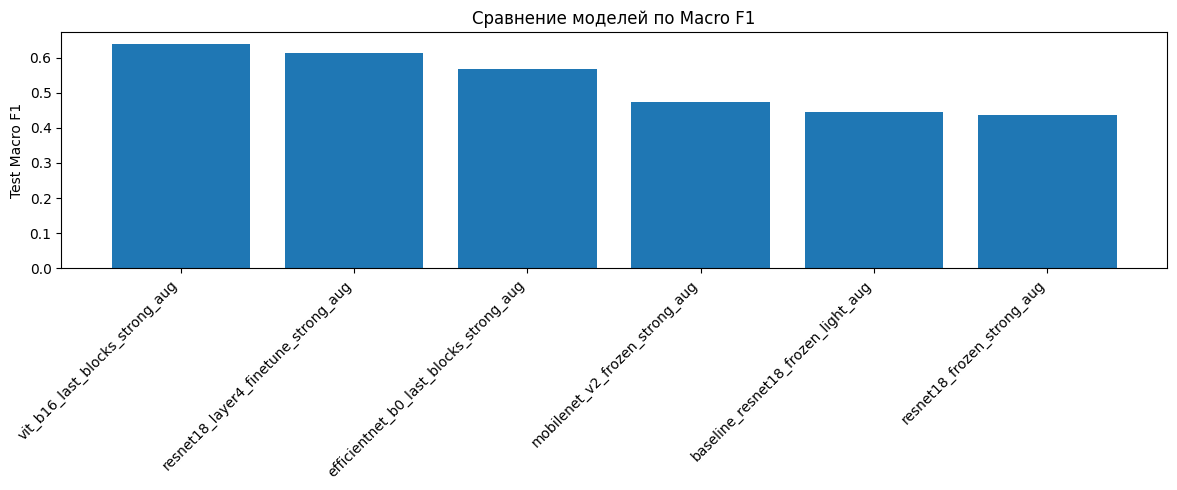

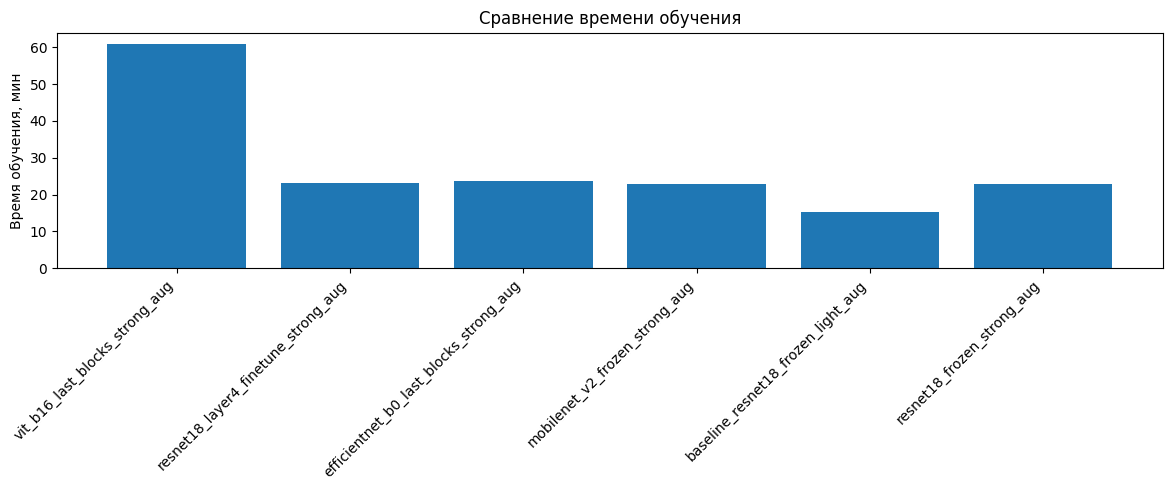

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["test_macro_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Macro F1")
plt.title("Сравнение моделей по Macro F1")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "experiments_macro_f1.png", dpi=200)
plt.show()
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["train_time_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Время обучения, мин")
plt.title("Сравнение времени обучения")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "experiments_train_time.png", dpi=200)
plt.show()

## Кривые обучения лучшей модели

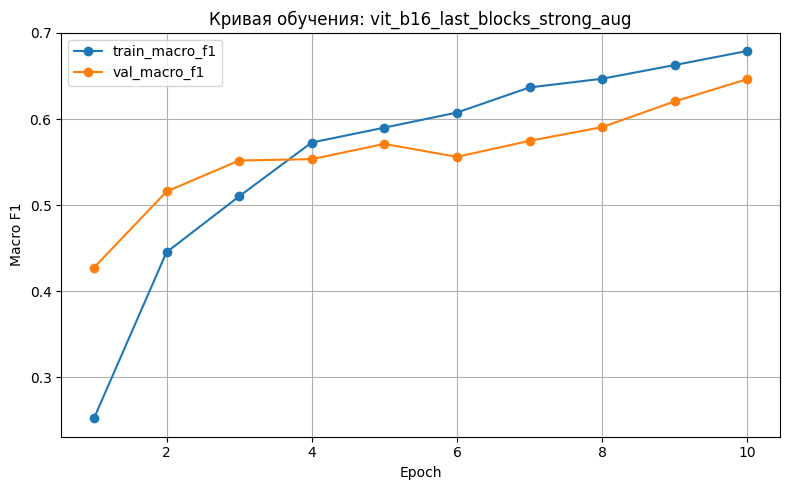

In [ ]:
best_exp = results_df.loc[0, "experiment"]
best_history = pd.read_csv(RESULTS_DIR / f"history_{best_exp}.csv")
plt.figure(figsize=(8, 5))
plt.plot(best_history["epoch"], best_history["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(best_history["epoch"], best_history["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title(f"Кривая обучения: {best_exp}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_model_learning_curve.png", dpi=200)
plt.show()

## Подробная оценка лучшей модели на test

  0%|          | 0/94 [00:00<?, ?it/s]

Best experiment: vit_b16_last_blocks_strong_aug
Accuracy: 0.737857618097139
Macro F1: 0.6407659287582363
ROC-AUC macro: 0.9514763286427864

              precision    recall  f1-score   support

       akiec       0.50      0.71      0.59        49
         bcc       0.63      0.75      0.69        77
         bkl       0.49      0.64      0.56       165
          df       0.38      0.71      0.49        17
         mel       0.40      0.63      0.49       167
          nv       0.96      0.77      0.85      1006
        vasc       0.72      0.95      0.82        22

    accuracy                           0.74      1503
   macro avg       0.58      0.74      0.64      1503
weighted avg       0.81      0.74      0.76      1503



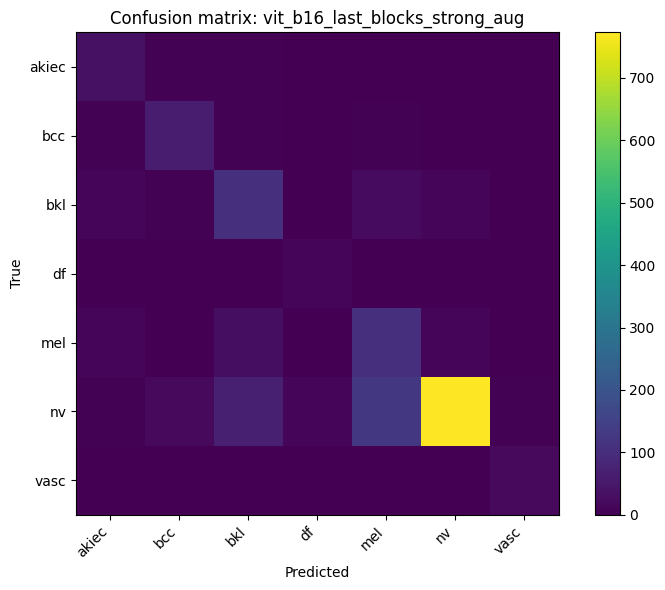

In [ ]:
best_row = results_df.iloc[0]
best_exp_name = best_row["experiment"]
best_config = next(exp for exp in experiments if exp["name"] == best_exp_name)
best_model = best_config["model_fn"]().to(DEVICE)
best_model.load_state_dict(torch.load(best_row["model_path"], map_location=DEVICE))
train_transform = light_train_transform if best_config["augmentation"] == "light" else strong_train_transform
_, _, test_loader = make_loaders(train_transform, batch_size=int(best_config["batch_size"]))
test_metrics = evaluate(best_model, test_loader, criterion, DEVICE)
print("Best experiment:", best_exp_name)
print("Accuracy:", test_metrics["accuracy"])
print("Macro F1:", test_metrics["macro_f1"])
print("ROC-AUC macro:", test_metrics["roc_auc_macro"])
print()
print(classification_report(test_metrics["targets"], test_metrics["preds"], target_names=classes))
cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion matrix: {best_exp_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_model_confusion_matrix.png", dpi=200)
plt.show()

## Выводы

В рамках чекпоинта были проведены эксперименты с несколькими DL-архитектурами для классификации медицинских изображений кожи. Были проверены как сверточные модели, так и transformer-based архитектура.

В качестве baseline использовалась ResNet-18 с замороженным backbone и light-аугментациями. Далее были проверены ResNet-18 со strong-аугментациями, ResNet-18 с fine-tuning последнего блока, MobileNetV2, EfficientNet-B0 и ViT-B/16.

Лучший результат показала модель ViT-B/16:

- Accuracy: 0.7379
- Macro F1: 0.6408
- ROC-AUC macro: 0.9515
- Время обучения: 60.98 мин

По главной метрике Macro F1 модель ViT-B/16 превзошла остальные архитектуры. Это важно, потому что датасет несбалансирован, и Accuracy не всегда честно отражает качество модели по редким классам. Macro F1 учитывает качество классификации по каждому классу независимо от его размера.

ResNet-18 с fine-tuning последнего блока заняла второе место:

- Accuracy: 0.7059
- Macro F1: 0.6150
- ROC-AUC macro: 0.9423
- Время обучения: 23.22 мин

Эта модель заметно лучше baseline, потому что fine-tuning последнего блока позволяет адаптировать высокоуровневые признаки ImageNet-модели под медицинские изображения. Также ResNet использует skip-connections, которые помогают стабильнее обучать глубокую сеть и уменьшают проблему затухания градиента.

EfficientNet-B0 показала средний результат: Macro F1 = 0.5689. Она эффективнее по числу обучаемых параметров, но в данном эксперименте уступила ResNet-18 fine-tuning и ViT-B/16.

MobileNetV2 оказалась быстрее и легче, но качество оказалось ниже: Macro F1 = 0.4749. Это объясняется тем, что архитектура оптимизирована под компактность и скорость, но хуже извлекает сложные визуальные признаки медицинских изображений.

Таким образом, transformer-based модель ViT-B/16 оказалась лучшим DL-решением. Вероятно, преимущество связано с механизмом self-attention, который позволяет модели учитывать связи между разными участками изображения, а не только локальные признаки, как в классических CNN.

## Краткое описание лучшего решения для отчёта

В качестве итогового DL-решения выбрана модель ViT-B/16 с предобученными весами ImageNet и fine-tuning последних encoder-блоков.

Итоговая конфигурация лучшей модели:

- Архитектура: Vision Transformer B/16
- Тип модели: transformer-based image classifier
- Основной механизм: self-attention
- Предобучение: ImageNet
- Аугментации: strong augmentation
- Оптимизатор: AdamW
- Learning rate: 1e-5
- Batch size: 16
- Количество эпох: 10
- Trainable parameters: 14 181 127
- Критерий качества для выбора лучшей модели: validation Macro F1

Итоговые test-метрики:

- Accuracy: 0.7379
- Macro F1: 0.6408
- ROC-AUC macro: 0.9515
- Время обучения: 60.98 мин

ViT-B/16 обучалась дольше остальных моделей, но дала лучший результат по Macro F1 и ROC-AUC macro. Поэтому увеличение времени обучения оправдано: модель лучше справляется с классификацией несбалансированных медицинских изображений и показывает более устойчивое качество по разным классам.

Итог: лучшей моделью является ViT-B/16, так как она показала максимальный Macro F1 среди всех проведённых экспериментов и лучше всего закрывает задачу классификации кожных новообразований.
